In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DATA_PATH = "/content/drive/MyDrive/SIS"

os.listdir(DATA_PATH)


['biflow_mqtt_bruteforce.csv',
 'biflow_normal.csv',
 'biflow_scan_sU.csv',
 'biflow_scan_A.csv',
 'biflow_sparta.csv']

In [ ]:
import pandas as pd
import numpy as np
normal_path = os.path.join(DATA_PATH, "biflow_normal.csv")
normal_df = pd.read_csv(normal_path)

print("Izgled normalnog dataseta:", normal_df.shape)
normal_df.head()


Izgled normalnog dataseta: (86008, 32)


,ip_src,ip_dst,prt_src,prt_dst,proto,fwd_num_pkts,bwd_num_pkts,fwd_mean_iat,bwd_mean_iat,fwd_std_iat,...,bwd_max_pkt_len,fwd_num_bytes,bwd_num_bytes,fwd_num_psh_flags,bwd_num_psh_flags,fwd_num_rst_flags,bwd_num_rst_flags,fwd_num_urg_flags,bwd_num_urg_flags,is_attack
0,10.0.0.5,192.168.1.7,56572,1883,6,7,5,0.000237,0.000203,0.000218,...,60.0,444,272,3,1,0,0,0,0,0
1,10.0.0.11,192.168.1.7,51906,1883,6,7,5,0.000242,0.000243,0.000207,...,60.0,483,272,3,1,0,0,0,0,0
2,10.0.0.14,192.168.1.7,54202,1883,6,7,5,0.000284,0.000349,0.000323,...,60.0,531,272,3,1,0,0,0,0,0
3,10.0.0.12,192.168.1.7,39782,1883,6,7,5,0.001038,0.000968,0.000895,...,60.0,462,272,3,1,0,0,0,0,0
4,10.0.0.13,192.168.1.7,38052,1883,6,7,5,0.001039,0.000968,0.000776,...,60.0,463,272,3,1,0,0,0,0,0


In [ ]:
normal_df.info()
normal_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86008 entries, 0 to 86007
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ip_src             86008 non-null  object 
 1   ip_dst             86008 non-null  object 
 2   prt_src            86008 non-null  int64  
 3   prt_dst            86008 non-null  int64  
 4   proto              86008 non-null  int64  
 5   fwd_num_pkts       86008 non-null  int64  
 6   bwd_num_pkts       86008 non-null  int64  
 7   fwd_mean_iat       86008 non-null  float64
 8   bwd_mean_iat       86008 non-null  float64
 9   fwd_std_iat        86008 non-null  float64
 10  bwd_std_iat        86008 non-null  float64
 11  fwd_min_iat        86008 non-null  float64
 12  bwd_min_iat        86008 non-null  float64
 13  fwd_max_iat        86008 non-null  float64
 14  bwd_max_iat        86008 non-null  float64
 15  fwd_mean_pkt_len   86008 non-null  float64
 16  bwd_mean_pkt_len   860

,prt_src,prt_dst,proto,fwd_num_pkts,bwd_num_pkts,fwd_mean_iat,bwd_mean_iat,fwd_std_iat,bwd_std_iat,fwd_min_iat,...,bwd_max_pkt_len,fwd_num_bytes,bwd_num_bytes,fwd_num_psh_flags,bwd_num_psh_flags,fwd_num_rst_flags,bwd_num_rst_flags,fwd_num_urg_flags,bwd_num_urg_flags,is_attack
count,86008.000000,86008.000000,86008.000000,86008.000000,86008.000000,86008.000000,86008.000000,86008.000000,86008.000000,86008.000000,...,86008.000000,8.600800e+04,8.600800e+04,86008.000000,86008.000000,86008.0,86008.0,86008.0,86008.0,86008.0
mean,45523.724014,1750.265964,6.797937,7.478444,5.623535,5.213081,5.213119,1.056890,1.056923,4.305349,...,60.819459,1.592768e+03,1.411072e+03,2.782392,0.927460,0.0,0.0,0.0,0.0,0.0
std,8051.593558,474.635302,2.853192,250.779835,250.783911,122.622907,122.622906,40.400196,40.400196,116.340749,...,5.808306,3.370718e+05,3.370724e+05,0.778154,0.259381,0.0,0.0,0.0,0.0,0.0
min,32768.000000,53.000000,6.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,60.000000,6.000000e+01,6.000000e+01,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
25%,38872.000000,1883.000000,6.000000,7.000000,5.000000,0.000315,0.000335,0.000293,0.000325,0.000004,...,60.000000,4.440000e+02,2.720000e+02,3.000000,1.000000,0.0,0.0,0.0,0.0,0.0
50%,44345.000000,1883.000000,6.000000,7.000000,5.000000,0.000402,0.000436,0.000404,0.000433,0.000005,...,60.000000,4.450000e+02,2.720000e+02,3.000000,1.000000,0.0,0.0,0.0,0.0,0.0
75%,51646.000000,1883.000000,6.000000,7.000000,5.000000,0.000534,0.000589,0.000565,0.000603,0.000013,...,60.000000,4.860000e+02,2.720000e+02,3.000000,1.000000,0.0,0.0,0.0,0.0,0.0
max,60998.000000,1883.000000,17.000000,73552.000000,73552.000000,5995.716184,5995.716184,2763.895226,2763.895201,5995.716184,...,1344.000000,9.885389e+07,9.885389e+07,4.000000,1.000000,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Uklanjanje ne-numeričkih i label stupaca
features_to_drop = ["ip_src", "ip_dst", "is_attack"]

X_normal = normal_df.drop(columns=features_to_drop)

print("Izgled nakon selektiranja:", X_normal.shape)
X_normal.head()


Izgled nakon selektiranja: (86008, 29)


,prt_src,prt_dst,proto,fwd_num_pkts,bwd_num_pkts,fwd_mean_iat,bwd_mean_iat,fwd_std_iat,bwd_std_iat,fwd_min_iat,...,fwd_max_pkt_len,bwd_max_pkt_len,fwd_num_bytes,bwd_num_bytes,fwd_num_psh_flags,bwd_num_psh_flags,fwd_num_rst_flags,bwd_num_rst_flags,fwd_num_urg_flags,bwd_num_urg_flags
0,56572,1883,6,7,5,0.000237,0.000203,0.000218,0.000193,0.000035,...,101.0,60.0,444,272,3,1,0,0,0,0
1,51906,1883,6,7,5,0.000242,0.000243,0.000207,0.000231,0.000013,...,112.0,60.0,483,272,3,1,0,0,0,0
2,54202,1883,6,7,5,0.000284,0.000349,0.000323,0.000397,0.000021,...,160.0,60.0,531,272,3,1,0,0,0,0
3,39782,1883,6,7,5,0.001038,0.000968,0.000895,0.001016,0.000003,...,100.0,60.0,462,272,3,1,0,0,0,0
4,38052,1883,6,7,5,0.001039,0.000968,0.000776,0.000924,0.000006,...,101.0,60.0,463,272,3,1,0,0,0,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_normal_scaled = scaler.fit_transform(X_normal)

X_normal_scaled.shape


(86008, 29)

In [ ]:
import numpy as np

print("Minimalna vrijednost:", np.min(X_normal_scaled))
print("Maksimalna vrijednost:", np.max(X_normal_scaled))


Minimalna vrijednost: 0.0
Maksimalna vrijednost: 1.0


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

input_dim = X_normal_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(32, activation="relu")(input_layer)
encoded = Dense(16, activation="relu")(encoded)

# Decoder
decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(input_dim, activation="sigmoid")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │           957 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,989 (11.68 KB)

 Trainable params: 2,989 (11.68 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    X_normal_scaled,
    X_normal_scaled,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

Epoch 1/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1104 - val_loss: 0.0020
Epoch 2/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0010 - val_loss: 3.7378e-04
Epoch 3/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.7246e-04 - val_loss: 1.9854e-04
Epoch 4/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.0276e-05 - val_loss: 1.6357e-04
Epoch 5/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.3026e-05 - val_loss: 1.4232e-04
Epoch 6/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.7280e-05 - val_loss: 1.2584e-04
Epoch 7/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.3953e-05 - val_loss: 1.0850e-04
Epoch 8/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.4760e-05 - val_loss: 9.7634e-05
Epoch 9/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.6244e-05 - val_loss: 9.2067e-05
Epoch 10/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.1589e-05 - val_loss: 8.5708e-05
Epoch 11/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.0051e-05

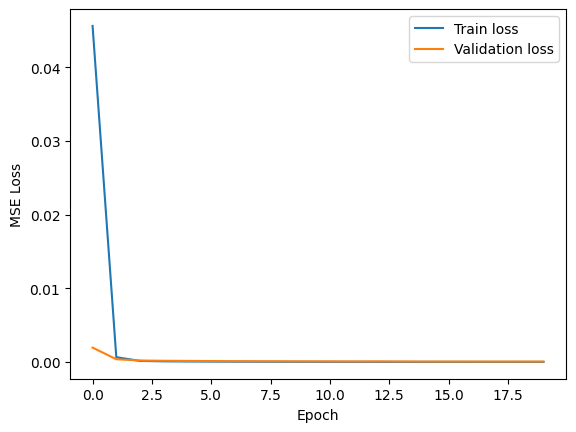

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


In [ ]:
# Rekonstrukcija normalnog prometa
reconstructions = autoencoder.predict(X_normal_scaled)

# Greška rekonstrukcije
reconstruction_error = np.mean(
    np.square(X_normal_scaled - reconstructions),
    axis=1
)

# Prag anomalije
threshold = np.percentile(reconstruction_error, 95)

print("Anomaly threshold:", threshold)


2688/2688 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Anomaly threshold: 2.2985487436026554e-05


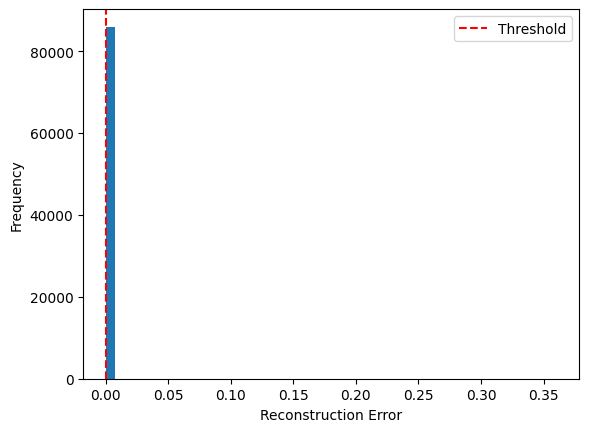

In [ ]:
plt.figure()
plt.hist(reconstruction_error, bins=50)
plt.axvline(threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [ ]:

attack_path = os.path.join(DATA_PATH, "biflow_mqtt_bruteforce.csv")
attack_df = pd.read_csv(attack_path)


X_attack = attack_df.drop(columns=["ip_src", "ip_dst", "is_attack"])

# Skaliranje
X_attack_scaled = scaler.transform(X_attack)

# Rekonstrukcija napadačkog prometa
attack_reconstructions = autoencoder.predict(X_attack_scaled)

# Greška rekonstrukcije
attack_error = np.mean(
    np.square(X_attack_scaled - attack_reconstructions),
    axis=1
)

# Detekcija anomalija
attack_anomalies = attack_error > threshold

print("Ukupno zapisa:", len(attack_anomalies))
print("Detektirane anomalije:", np.sum(attack_anomalies))
print("Postotak detekcije:", np.mean(attack_anomalies) * 100, "%")


522/522 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step
Ukupno zapisa: 16696
Detektirane anomalije: 14648
Postotak detekcije: 87.73358888356493 %


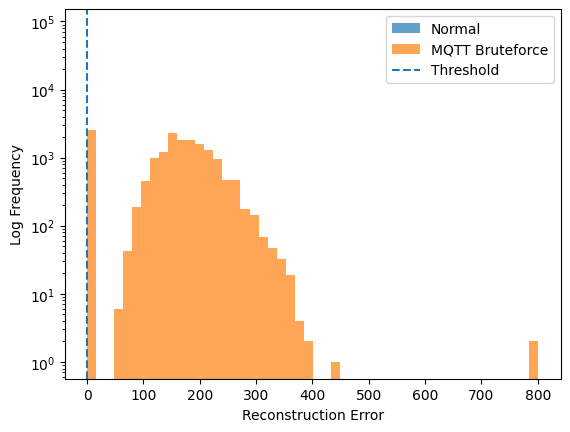

In [ ]:
plt.figure()
plt.hist(reconstruction_error, bins=50, alpha=0.7, label="Normal")
plt.hist(attack_error, bins=50, alpha=0.7, label="MQTT Bruteforce")
plt.axvline(threshold, linestyle='--', label="Threshold")
plt.yscale("log")
plt.xlabel("Reconstruction Error")
plt.ylabel("Log Frequency")
plt.legend()
plt.show()

In [ ]:
attack_df["reconstruction_error"] = attack_error
attack_df["detected"] = attack_error > threshold

Broj propuštenih zapisa

In [ ]:
missed_attacks = attack_df[attack_df["detected"] == False]
print("Broj propuštenih zapisa:", len(missed_attacks))

Broj propuštenih zapisa: 2048


Usporedba detektiranih i propuštenih anomalija

In [ ]:
comparison = pd.DataFrame({
    "Detected_Attacks": detected_attacks[numeric_cols].mean(),
    "Missed_Attacks": missed_attacks[numeric_cols].mean()
})

comparison


,Detected_Attacks,Missed_Attacks
prt_src,46985.698662,46270.071289
prt_dst,1818.953236,53.000000
proto,6.400259,17.000000
fwd_num_pkts,343.747406,2.120117
bwd_num_pkts,343.069907,2.120117
fwd_mean_iat,4.043117,0.726024
bwd_mean_iat,4.050492,0.726022
fwd_std_iat,10.457984,0.816769
bwd_std_iat,10.468323,0.816766
fwd_min_iat,0.552649,0.148479


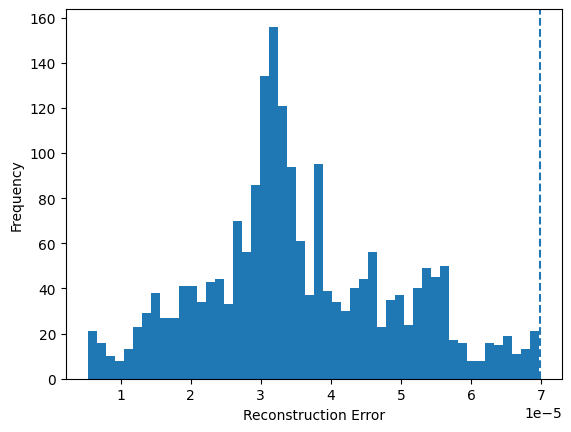

In [ ]:
plt.hist(missed_attacks["reconstruction_error"], bins=50)
plt.axvline(threshold, linestyle="--")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()
